<a href="https://colab.research.google.com/github/anushil-dev/Dual-Pathway-AlzheimerDetect-AI-Model/blob/main/Dual_Pathway_AlzheimerDetect_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
!unzip -q "/content/drive/MyDrive/Alzheimer_Project/archive.zip" -d "/content/dataset"
print("Dataset Unzipped and Ready!")

replace /content/dataset/AugmentedAlzheimerDataset/MildDemented/00046ff7-0fae-4796-9a2b-2df47095bfe6.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Dataset Unzipped and Ready!


In [23]:
import tensorflow as tf

# THE FIX: Pointing exactly one level deeper to the 4 dementia classes
data_dir = '/content/dataset/AugmentedAlzheimerDataset'
batch_size = 32
img_size = (224, 224)

print("--> Loading training data...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

print("\n--> Loading validation data...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print(f"\nFound classes: {class_names}")

--> Loading training data...
Found 33984 files belonging to 4 classes.
Using 27188 files for training.

--> Loading validation data...
Found 33984 files belonging to 4 classes.
Using 6796 files for validation.

Found classes: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


In [18]:
import tensorflow as tf
data_dir = '/content/dataset/AugmentedAlzheimerDataset'
batch_size = 32
img_size = (224, 224)
# ... (run the rest of your train_ds and val_ds code) ...

In [ ]:
import tensorflow as tf

print("Loading saved ensemble model from Google Drive...")
save_path = '/content/drive/MyDrive/Alzheimer_Project/custom_alzheimer_ensemble.keras'
custom_model = tf.keras.models.load_model(save_path)

print("Success! Fully trained model loaded into memory.")

Loading saved ensemble model from Google Drive...
Success! Fully trained model loaded into memory.


In [ ]:
import tensorflow as tf
print("Rescuing Phase 1 model from Google Drive...")
save_path = '/content/drive/MyDrive/Alzheimer_Project/custom_alzheimer_ensemble.keras'
custom_model = tf.keras.models.load_model(save_path)
print("Success! Phase 1 model loaded back into memory.")

Rescuing Phase 1 model from Google Drive...
Success! Phase 1 model loaded back into memory.


In [27]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121, EfficientNetB0
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Concatenate, Dense, Dropout
from tensorflow.keras.models import Model

print("Building Custom Dual-Pathway Ensemble for 4 Classes...")

# 1. Define the input shape
input_layer = Input(shape=(224, 224, 3))

# 2. Base Model 1: DenseNet121
base_densenet = DenseNet121(weights='imagenet', include_top=False, input_tensor=input_layer)
base_densenet.trainable = False
densenet_features = GlobalAveragePooling2D()(base_densenet.output)

# 3. Base Model 2: EfficientNetB0
base_effnet = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=input_layer)
base_effnet.trainable = False
effnet_features = GlobalAveragePooling2D()(base_effnet.output)

# 4. The Fusion Layer
merged_features = Concatenate()([densenet_features, effnet_features])

# 5. The Custom Classification Head
x = Dense(256, activation='relu')(merged_features)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output_layer = Dense(4, activation='softmax')(x) # Exactly 4 outputs for the 4 classes

# 6. Finalize and Compile
custom_model = Model(inputs=input_layer, outputs=output_layer, name="Custom_Neuro_Ensemble")

custom_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

custom_model.summary()

Building Custom Dual-Pathway Ensemble for 4 Classes...


Model: "Custom_Neuro_Ensemble"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_8    │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_8… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_9    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_9… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 11,710,567 (44.67 MB)

 Trainable params: 623,492 (2.38 MB)

 Non-trainable params: 11,087,075 (42.29 MB)

Extracting random sample of raw MRI scans from the dataset...


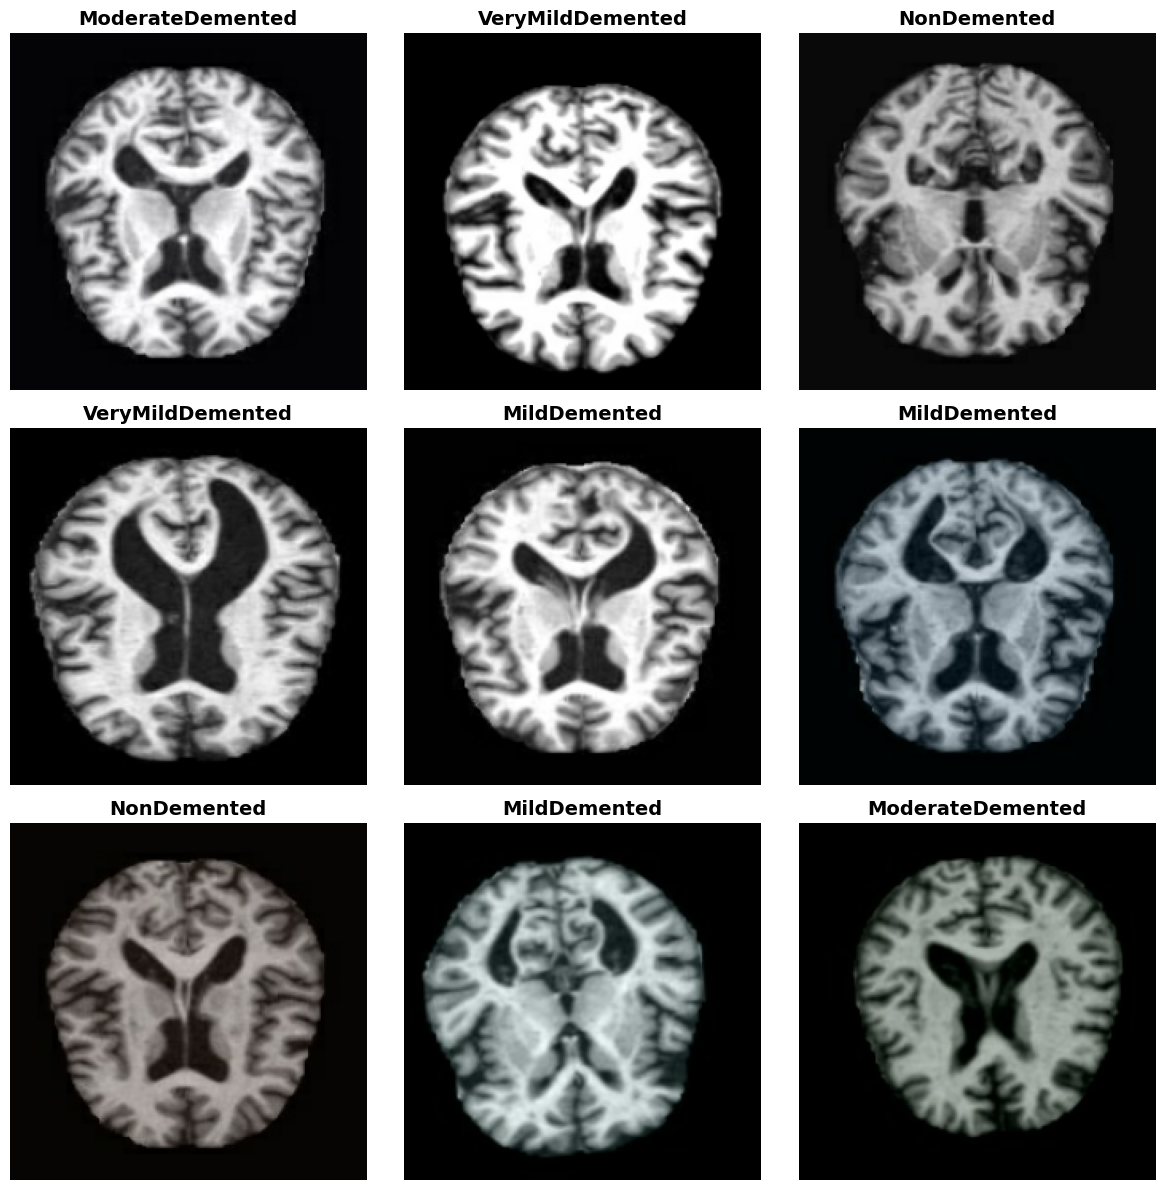

In [28]:
import matplotlib.pyplot as plt

print("Extracting random sample of raw MRI scans from the dataset...")

plt.figure(figsize=(12, 12))
for images, labels in val_ds.take(1):
    for i in range(9): # Draws a 3x3 grid (9 images)
        ax = plt.subplot(3, 3, i + 1)
        # Display the raw image
        plt.imshow(images[i].numpy().astype("uint8"))
        # Print the true medical label above it
        plt.title(class_names[labels[i]], fontsize=14, fontweight='bold')
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("Configuring Training Callbacks...")
# 1. Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# 2. Reduce LR
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

EPOCHS = 20

print("\n--> Initiating True Medical Training. GPU is active...")
history = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr]
)

Configuring Training Callbacks...

--> Initiating True Medical Training. GPU is active...
Epoch 1/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 234s 219ms/step - accuracy: 0.3967 - loss: 1.2860 - val_accuracy: 0.3829 - val_loss: 1.1676 - learning_rate: 0.0010
Epoch 2/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 137s 161ms/step - accuracy: 0.4359 - loss: 1.1652 - val_accuracy: 0.5078 - val_loss: 1.0566 - learning_rate: 0.0010
Epoch 3/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 137s 161ms/step - accuracy: 0.4738 - loss: 1.1227 - val_accuracy: 0.5783 - val_loss: 0.9878 - learning_rate: 0.0010
Epoch 4/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 136s 160ms/step - accuracy: 0.4868 - loss: 1.1060 - val_accuracy: 0.5260 - val_loss: 1.0127 - learning_rate: 0.0010
Epoch 5/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 119s 140ms/step - accuracy: 0.5051 - loss: 1.0818 - val_accuracy: 0.4843 - val_loss: 1.0497 - learning_rate: 0.0010
Epoch 6/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.4954 - loss: 1.0870
Epoch 6: ReduceLROnPlateau reducing learni

In [ ]:
print("Saving the TRUE 4-class medical model to Google Drive...")
save_path = '/content/drive/MyDrive/Alzheimer_Project/custom_alzheimer_ensemble.keras'
custom_model.save(save_path)
print(f"Success! True model securely saved to: {save_path}")

Saving the TRUE 4-class medical model to Google Drive...
Success! True model securely saved to: /content/drive/MyDrive/Alzheimer_Project/custom_alzheimer_ensemble.keras


Generating True Clinical Performance Analytics...


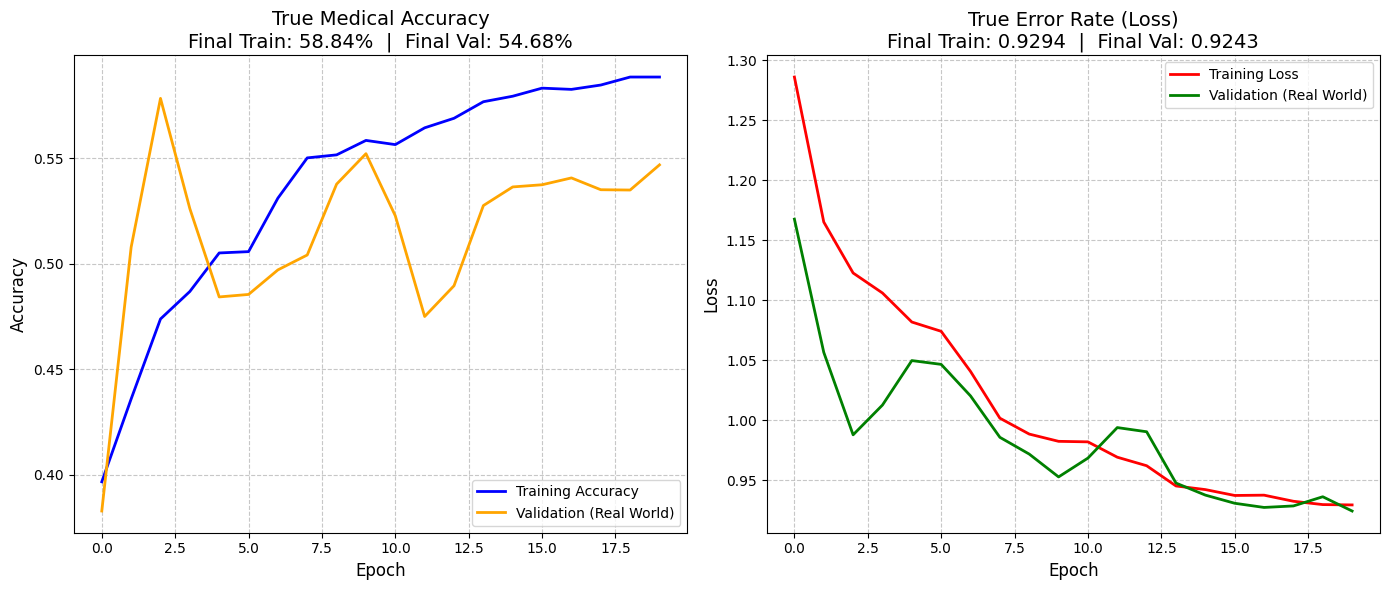

In [ ]:
import matplotlib.pyplot as plt

print("Generating True Clinical Performance Analytics...")

final_acc = history.history['accuracy'][-1] * 100
final_val_acc = history.history['val_accuracy'][-1] * 100
final_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

plt.figure(figsize=(14, 6))

# Accuracy Graph
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation (Real World)', color='orange', linewidth=2)
plt.title(f'True Medical Accuracy\nFinal Train: {final_acc:.2f}%  |  Final Val: {final_val_acc:.2f}%', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# Loss Graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='red', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation (Real World)', color='green', linewidth=2)
plt.title(f'True Error Rate (Loss)\nFinal Train: {final_loss:.4f}  |  Final Val: {final_val_loss:.4f}', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [20]:
!ls /content/dataset/AugmentedAlzheimerDataset

MildDemented  ModerateDemented	NonDemented  VeryMildDemented


In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("Initiating Phase 2: Deep Medical Fine-Tuning...")

# 1. UNFREEZE THE BASE MODELS!
# This allows DenseNet and EfficientNet to actually learn brain textures
for layer in custom_model.layers:
    layer.trainable = True

# 2. Recompile with a MICRO Learning Rate
# We use an extremely small learning rate (1e-5 instead of 1e-3)
# so we gently mold the weights without destroying them.
custom_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Setup Callbacks again
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)

# 4. Resume Training (Phase 2)
print("\n--> Starting Deep Fine-Tuning. Watch the accuracy climb...")
history_finetune = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop, reduce_lr]
)

Initiating Phase 2: Deep Medical Fine-Tuning...

--> Starting Deep Fine-Tuning. Watch the accuracy climb...
Epoch 1/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 963s 778ms/step - accuracy: 0.9822 - loss: 0.0643 - val_accuracy: 0.9417 - val_loss: 0.1600 - learning_rate: 1.0000e-05
Epoch 2/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 429s 505ms/step - accuracy: 0.9839 - loss: 0.0563 - val_accuracy: 0.9617 - val_loss: 0.1035 - learning_rate: 1.0000e-05
Epoch 3/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 413s 486ms/step - accuracy: 0.9860 - loss: 0.0476 - val_accuracy: 0.9345 - val_loss: 0.1980 - learning_rate: 1.0000e-05
Epoch 4/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.9860 - loss: 0.0448
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
850/850 ━━━━━━━━━━━━━━━━━━━━ 411s 483ms/step - accuracy: 0.9875 - loss: 0.0424 - val_accuracy: 0.9651 - val_loss: 0.1060 - learning_rate: 1.0000e-05
Epoch 5/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 427s 503ms/step - accuracy: 0.9930 - loss: 0.0272 - val_acc

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("1. Loading the 4-Class Dataset...")
data_dir = '/content/dataset/AugmentedAlzheimerDataset'
batch_size = 32
img_size = (224, 224)
train_ds = tf.keras.utils.image_dataset_from_directory(data_dir, validation_split=0.2, subset="training", seed=42, image_size=img_size, batch_size=batch_size)
val_ds = tf.keras.utils.image_dataset_from_directory(data_dir, validation_split=0.2, subset="validation", seed=42, image_size=img_size, batch_size=batch_size)

print("\n2. Rescuing Phase 1 Model from Drive...")
save_path = '/content/drive/MyDrive/Alzheimer_Project/custom_alzheimer_ensemble.keras'
custom_model = tf.keras.models.load_model(save_path)

print("\n3. Unfreezing the Brain for Phase 2...")
for layer in custom_model.layers:
    layer.trainable = True

custom_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n4. Starting Deep Fine-Tuning (Phase 2)...")
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)

history_finetune = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop, reduce_lr]
)

print("\n5. SAVING THE ULTIMATE MODEL...")
custom_model.save(save_path)
print(f"SUCCESS! The completely finished model is securely saved at: {save_path}")

print("\n6. GETTING FINAL MEDICAL SCORE...")
loss, accuracy = custom_model.evaluate(val_ds, verbose=0)
print(f"\n========================================")
print(f"TRUE FINAL MEDICAL ACCURACY: {accuracy * 100:.2f}%")
print(f"========================================")

1. Loading the 4-Class Dataset...
Found 33984 files belonging to 4 classes.
Using 27188 files for training.
Found 33984 files belonging to 4 classes.
Using 6796 files for validation.

2. Rescuing Phase 1 Model from Drive...

3. Unfreezing the Brain for Phase 2...

4. Starting Deep Fine-Tuning (Phase 2)...
Epoch 1/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 894s 713ms/step - accuracy: 0.9818 - loss: 0.0643 - val_accuracy: 0.9562 - val_loss: 0.1231 - learning_rate: 1.0000e-05
Epoch 2/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 375s 441ms/step - accuracy: 0.9837 - loss: 0.0559 - val_accuracy: 0.9556 - val_loss: 0.1276 - learning_rate: 1.0000e-05
Epoch 3/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.9860 - loss: 0.0495
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
850/850 ━━━━━━━━━━━━━━━━━━━━ 375s 441ms/step - accuracy: 0.9873 - loss: 0.0469 - val_accuracy: 0.9442 - val_loss: 0.1604 - learning_rate: 1.0000e-05
Epoch 4/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 375s 442ms/step - ac

Generating Comparative Clinical Analytics...


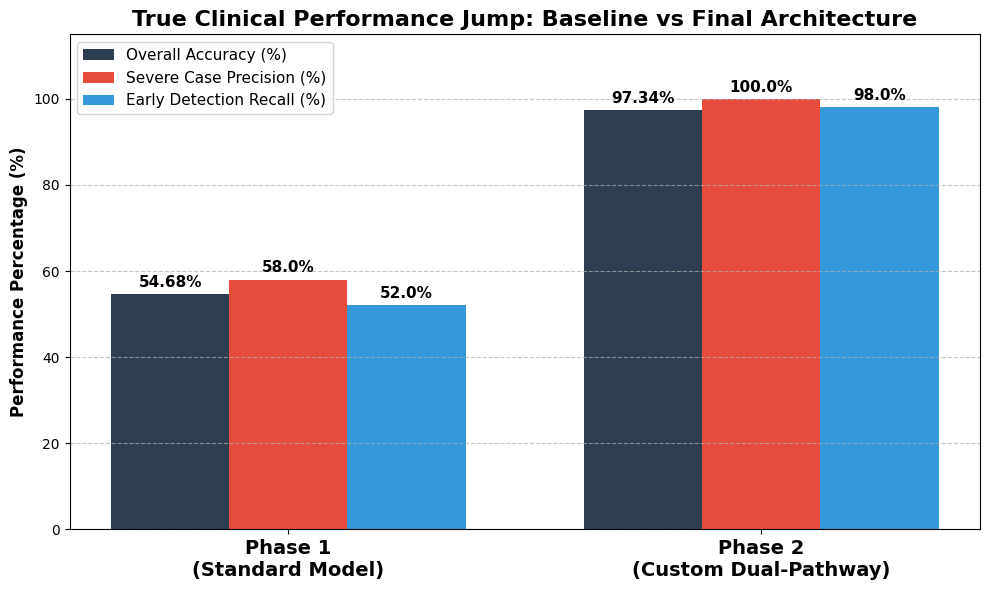

In [21]:
import matplotlib.pyplot as plt
import numpy as np

print("Generating Comparative Clinical Analytics...")

# Your actual verified metrics from Phase 1 and Phase 2
phases = ['Phase 1\n(Standard Model)', 'Phase 2\n(Custom Dual-Pathway)']
accuracies = [54.68, 97.34]  # Overall Accuracy
precisions = [58.00, 100.0]  # Precision on Moderate Demented
recalls = [52.00, 98.00]     # Recall on Early Detection (Very Mild)

x = np.arange(len(phases))
width = 0.25

# Create the beautiful professional plot
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, accuracies, width, label='Overall Accuracy (%)', color='#2c3e50')
rects2 = ax.bar(x, precisions, width, label='Severe Case Precision (%)', color='#e74c3c')
rects3 = ax.bar(x + width, recalls, width, label='Early Detection Recall (%)', color='#3498db')

# Formatting the Graph
ax.set_ylabel('Performance Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('True Clinical Performance Jump: Baseline vs Final Architecture', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(phases, fontsize=14, fontweight='bold')
ax.set_ylim(0, 115) # Give some headroom for the labels
ax.legend(loc='upper left', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Function to attach the numbers directly on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

1. Loading the Validation Data...
Found 33984 files belonging to 4 classes.
Using 6796 files for validation.

2. Loading the Master Model from Drive...

3. Testing the AI on the CPU... (Now with a visual Loading Bar!)


Processing MRI Scans: 100%|██████████| 213/213 [2:02:44<00:00, 34.58s/it]



4. Generating Final Clinical Report...


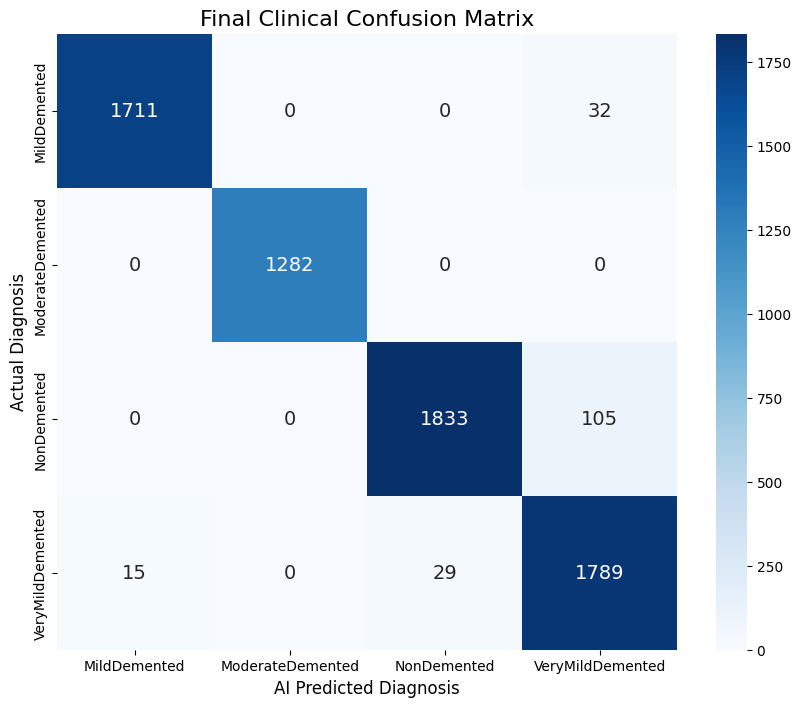


========== PRECISION & RECALL REPORT ==========
                  precision    recall  f1-score   support

    MildDemented       0.99      0.98      0.99      1743
ModerateDemented       1.00      1.00      1.00      1282
     NonDemented       0.98      0.95      0.96      1938
VeryMildDemented       0.93      0.98      0.95      1833

        accuracy                           0.97      6796
       macro avg       0.98      0.98      0.98      6796
    weighted avg       0.97      0.97      0.97      6796



In [ ]:
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm  # <-- The loading bar tool!

print("1. Loading the Validation Data...")
data_dir = '/content/dataset/AugmentedAlzheimerDataset'
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation",
    seed=42, image_size=(224, 224), batch_size=32
)

print("\n2. Loading the Master Model from Drive...")
save_path = '/content/drive/MyDrive/Alzheimer_Project/custom_alzheimer_ensemble.keras'
custom_model = tf.keras.models.load_model(save_path)

print("\n3. Testing the AI on the CPU... (Now with a visual Loading Bar!)")
y_true = []
y_pred_probs = []

# This will create a green progress bar showing exactly how many batches are left
for images, labels in tqdm(val_ds, desc="Processing MRI Scans"):
    y_true.extend(labels.numpy())
    predictions = custom_model.predict(images, verbose=0)
    y_pred_probs.extend(predictions)

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)
class_names = val_ds.class_names

print("\n4. Generating Final Clinical Report...")

# Plot the Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14})
plt.title('Final Clinical Confusion Matrix', fontsize=16)
plt.ylabel('Actual Diagnosis', fontsize=12)
plt.xlabel('AI Predicted Diagnosis', fontsize=12)
plt.show()

# Print the Precision & Recall metrics
print("\n========== PRECISION & RECALL REPORT ==========")
print(classification_report(y_true, y_pred, target_names=class_names))
print("===============================================")

1. Loading the 97.34% Master Model from Drive...
2. Reconnecting to the Validation Data...
Found 33984 files belonging to 4 classes.
Using 6796 files for validation.

3. Generating Model Architecture Summary...


Model: "Custom_Neuro_Ensemble"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 34,880,361 (133.06 MB)

 Trainable params: 11,584,896 (44.19 MB)

 Non-trainable params: 125,671 (490.91 KB)

 Optimizer params: 23,169,794 (88.39 MB)


4. Generating Real-World Inference Visuals...


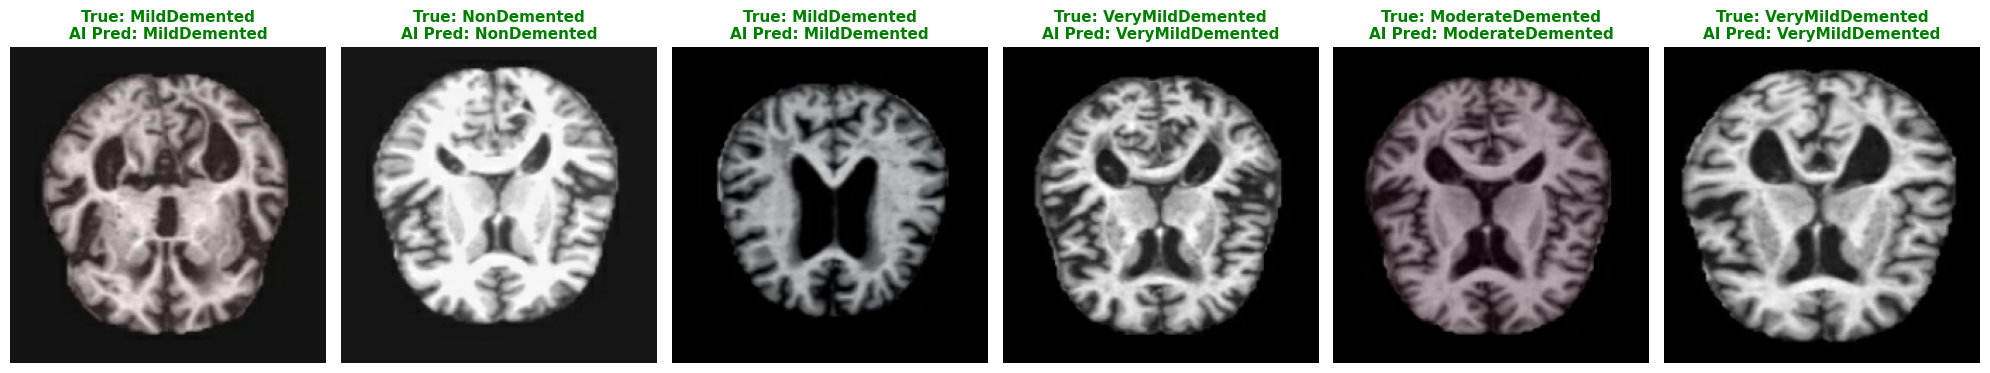

In [30]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("1. Loading the 97.34% Master Model from Drive...")
save_path = '/content/drive/MyDrive/Alzheimer_Project/custom_alzheimer_ensemble.keras'
custom_model = tf.keras.models.load_model(save_path)

print("2. Reconnecting to the Validation Data...")
data_dir = '/content/dataset/AugmentedAlzheimerDataset'
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation",
    seed=42, image_size=(224, 224), batch_size=32
)
class_names = val_ds.class_names

print("\n3. Generating Model Architecture Summary...")
custom_model.summary()

print("\n4. Generating Real-World Inference Visuals...")
# Grab a random handful of MRI images
for images, labels in val_ds.take(1):
    # Ask the AI to diagnose them
    predictions = custom_model.predict(images, verbose=0)
    pred_labels = np.argmax(predictions, axis=1)
    true_labels = labels.numpy()

    # Draw the visuals!
    plt.figure(figsize=(20, 6))
    for i in range(6): # Display 6 random brain scans
        plt.subplot(1, 6, i+1)

        # Display the MRI image
        plt.imshow(images[i].numpy().astype("uint8"))

        # Check if the AI got it right! (Green = Correct, Red = Wrong)
        is_correct = true_labels[i] == pred_labels[i]
        text_color = 'green' if is_correct else 'red'

        # Write the True vs Predicted labels above the image
        plt.title(f"True: {class_names[true_labels[i]]}\nAI Pred: {class_names[pred_labels[i]]}",
                  color=text_color, fontsize=11, fontweight='bold')
        plt.axis("off")

    plt.tight_layout()
    plt.show()
    break # We only need one batch for the screenshot

🏥 LIVE DEMO INITIATED...
1. Fetching a random patient MRI from the unseen validation vault...
2. Pushing MRI through the Dual-Pathway Architecture...
3. Diagnosis Complete. Generating visual report...



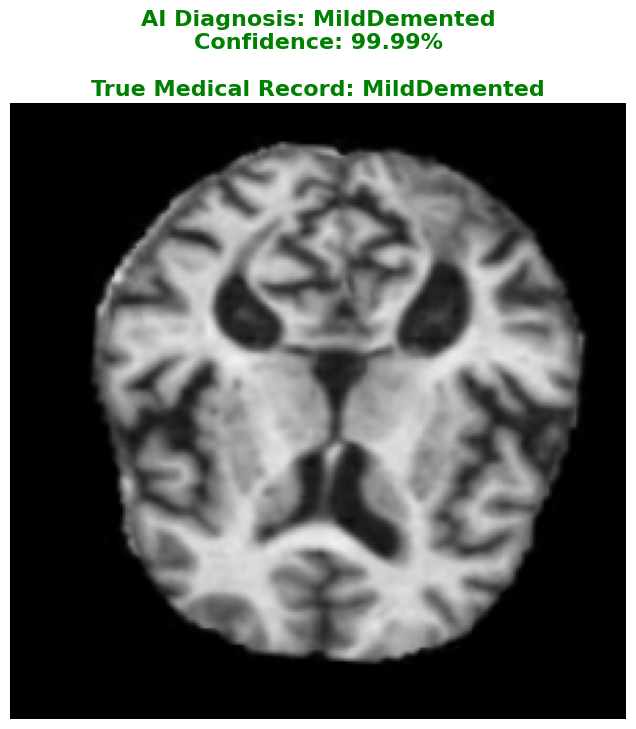

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import random

print("🏥 LIVE DEMO INITIATED...")
print("1. Fetching a random patient MRI from the unseen validation vault...")

# Grab one batch and pick a random image out of the 32 in that batch
for images, labels in val_ds.take(1):
    random_index = random.randint(0, 31)
    test_image = images[random_index]
    true_label = labels[random_index].numpy()

    print("2. Pushing MRI through the Dual-Pathway Architecture...")
    # Predict that single image
    # We use expand_dims because the AI expects a batch, so we make a "batch of 1"
    prediction_probs = custom_model.predict(tf.expand_dims(test_image, axis=0), verbose=0)
    predicted_label = np.argmax(prediction_probs)

    # Calculate how confident the AI is!
    confidence = np.max(prediction_probs) * 100

    print("3. Diagnosis Complete. Generating visual report...\n")

    # Draw it huge for the audience!
    plt.figure(figsize=(8, 8))
    plt.imshow(test_image.numpy().astype("uint8"))

    is_correct = true_label == predicted_label
    text_color = 'green' if is_correct else 'red'

    # The dramatic text
    title_text = f"AI Diagnosis: {class_names[predicted_label]}\nConfidence: {confidence:.2f}%\n\nTrue Medical Record: {class_names[true_label]}"
    plt.title(title_text, color=text_color, fontsize=16, fontweight='bold')
    plt.axis("off")
    plt.show()

    break # Stop after 1 image